# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset yang digunakan adalah **Bank Transaction Dataset for Fraud Detection**, sumber: https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection/data
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Dataset berisikan 2512 baris, memenuhi kriteria minimal 2500 baris.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - **Kategorikal**: TransactionType, Channel, CustomerOccupation, dsb.
     - **Numerikal**: TransactionID, AccountID, DeviceID, dsb.

3. **Pembatasan**:  
   Dataset yang digunakan diambil mentah dari Kaggle, belum dipakai untuk latihan clustering.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd  # Manipulasi dan analisis data
import matplotlib.pyplot as plt  # Visualisasi grafik
import seaborn as sns  # Visualisasi data yang lebih cantik
import numpy as np  # Operasi numerik
import kagglehub
from kagglehub import KaggleDatasetAdapter
from yellowbrick.cluster import KElbowVisualizer  # Visualisasi metode Elbow

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler  # LabelEncoder dan StandardScaler untuk preprocessing data
from sklearn.cluster import KMeans # KMeans dan DBSCAN untuk clustering
from sklearn.metrics import silhouette_score  # silhouette_score untuk mengevaluasi hasil clustering
from sklearn.decomposition import PCA

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [2]:
file_path = "bank_transactions_data_2.csv"

df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "valakhorasani/bank-transaction-dataset-for-fraud-detection", file_path)

df.head()

<ipython-input-2-5e41e266d59c>:3: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "valakhorasani/bank-transaction-dataset-for-fraud-detection", file_path)


100%|██████████| 337k/337k [00:00<00:00, 818kB/s]


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

1. Cek isi dataframe

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

`TransactionDate` dan `PreviousTransactionDate` seharusnya dalam tipe data `datetime`

In [4]:
df.duplicated().sum()

np.int64(0)

Tidak ada adata duplikat

In [5]:
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


Tidak ada data kosong

2. Cek statistik dalam dataframe, dan korelasinya satu sama lain.

In [6]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


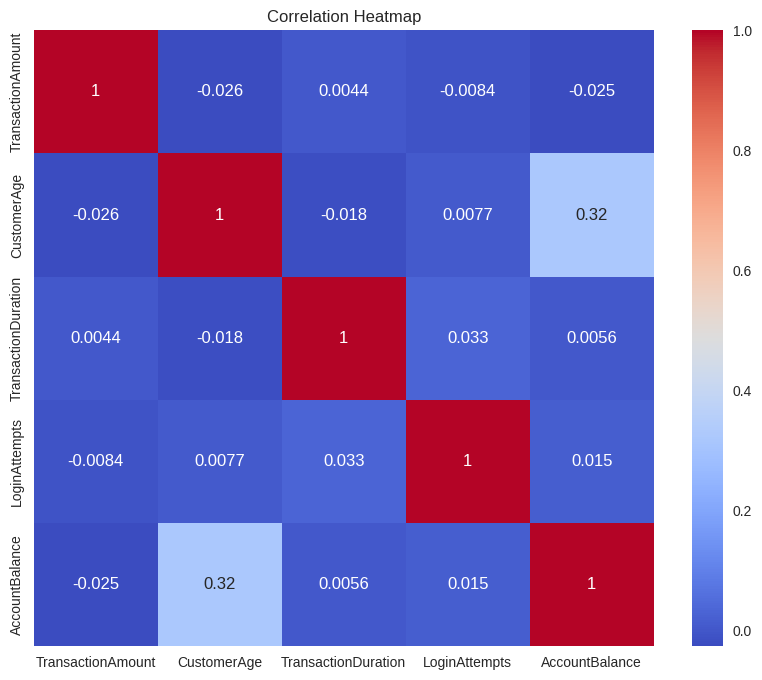

In [7]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

3. Cek isi dari `CustomerAge` dan distribusinya

In [8]:
df['CustomerAge'].unique()

array([70, 68, 19, 26, 18, 37, 67, 51, 55, 52, 21, 24, 36, 39, 59, 71, 38,
       22, 65, 23, 44, 27, 29, 49, 45, 75, 66, 63, 57, 74, 41, 69, 28, 62,
       25, 48, 46, 79, 56, 50, 42, 60, 32, 35, 20, 58, 34, 54, 64, 53, 30,
       78, 40, 47, 43, 33, 80, 77, 61, 31, 76, 73, 72])

In [9]:
length = len(df['CustomerAge'].unique())
print(length)

63


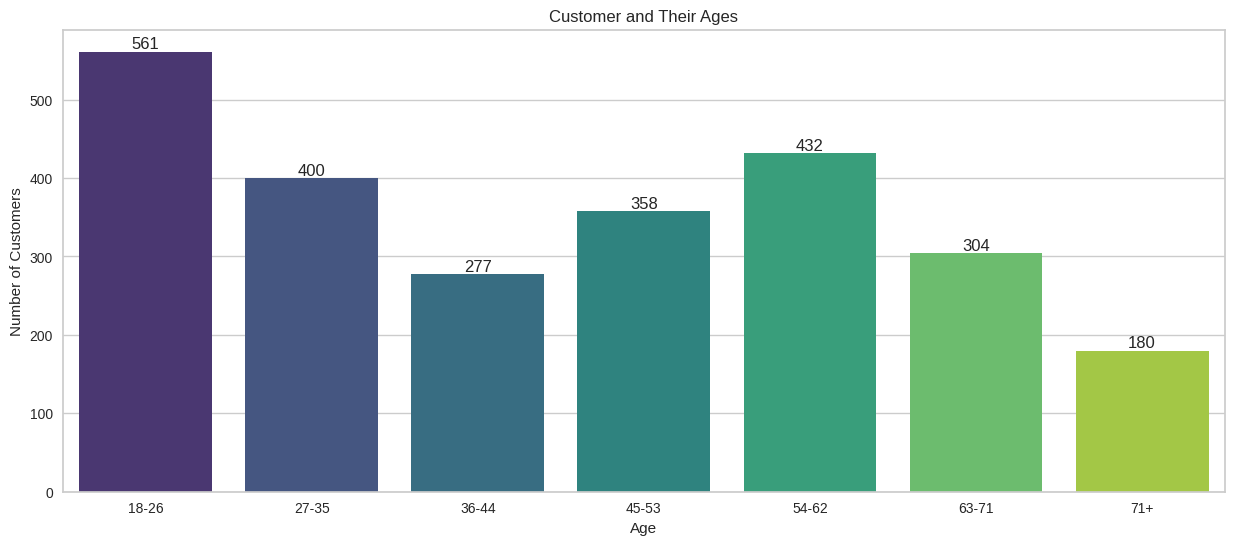

In [10]:
# Mengelompokkan usia pelanggan ke dalam 8 kategori dengan range umur 8 tahun, dan menghitung jumlah pelanggan di setiap kategori
age18_26 = df[(df.CustomerAge >= 18) & (df.CustomerAge <= 26)]
age27_35 = df[(df.CustomerAge >= 27) & (df.CustomerAge <= 35)]
age36_44 = df[(df.CustomerAge >= 36) & (df.CustomerAge <= 44)]
age45_53 = df[(df.CustomerAge >= 45) & (df.CustomerAge <= 53)]
age54_62 = df[(df.CustomerAge >= 54) & (df.CustomerAge <= 62)]
age63_71 = df[(df.CustomerAge >= 63) & (df.CustomerAge <= 71)]
age71above = df[df.CustomerAge > 71]

# Menyusun data untuk plotting
x = ["18-26", "27-35", "36-44", "45-53", "54-62", "63-71", "71+"]
y = [len(age18_26), len(age27_35), len(age36_44), len(age45_53), len(age54_62),len(age63_71), len(age71above)]
data = pd.DataFrame({'Age': x, 'Number of Customers': y})

# Membuat bar chart untuk distribusi usia pelanggan
plt.figure(figsize=(15, 6))
sns.barplot(x=x, y=y, data=data, hue = x, palette='viridis')
plt.title("Customer and Their Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

# Menambahkan label jumlah pelanggan di atas setiap bar
for i in range(len(x)):
  plt.text(i, y[i], y[i], ha='center', va='bottom')

plt.show()

Karena menurut tabel korelasi, ada korelasi rendah-moderat antara `CustomerAge` dengan `AccountBalance`, kita coba cek grafik korelasinya.

Text(0.5, 1.0, 'Distribution of Customer Age vs Account Balance')

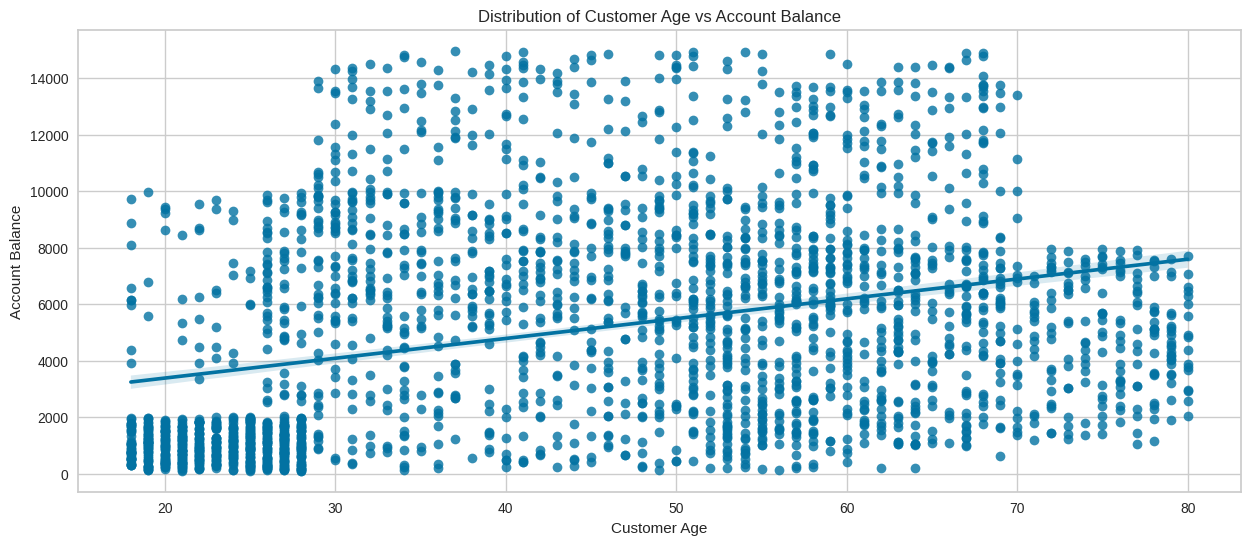

In [11]:
plt.figure(figsize=(15, 6))
sns.regplot(x=df['CustomerAge'], y=df['AccountBalance'])
plt.xlabel('Customer Age')
plt.ylabel('Account Balance')
plt.title('Distribution of Customer Age vs Account Balance')

Text(0.5, 1.0, 'Distribution of Customer Age vs Account Balance')

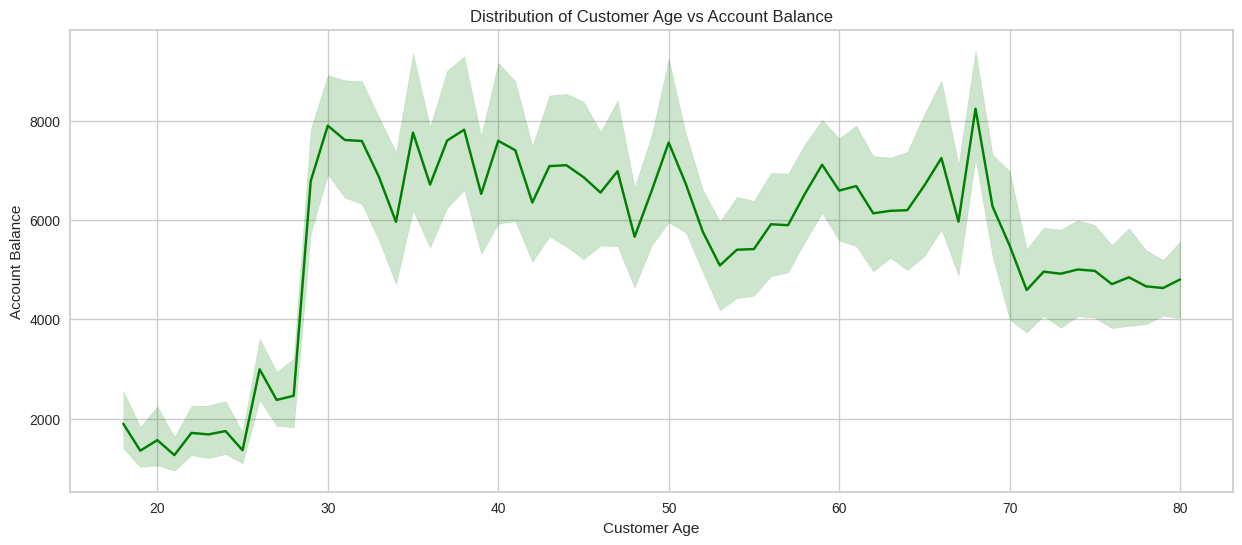

In [12]:
plt.figure(figsize=(15, 6))
sns.lineplot(x=df['CustomerAge'], y=df['AccountBalance'], color='green')
plt.xlabel('Customer Age')
plt.ylabel('Account Balance')
plt.title('Distribution of Customer Age vs Account Balance')

Mayoritas pengguna berusia di bawah 30 tahun memiliki tabungan tidak lebih dari USD 2000. Namun angka itu melejit mulai usia 29 tahun yang mana mulai umur tersebut, lebih banyak pengguna yang mempunyai tabungan lebih dari USD 2000

4. Cek isi `CustomerOccupation` dan disrtribusinya

In [13]:
df['CustomerOccupation'].unique()

array(['Doctor', 'Student', 'Retired', 'Engineer'], dtype=object)

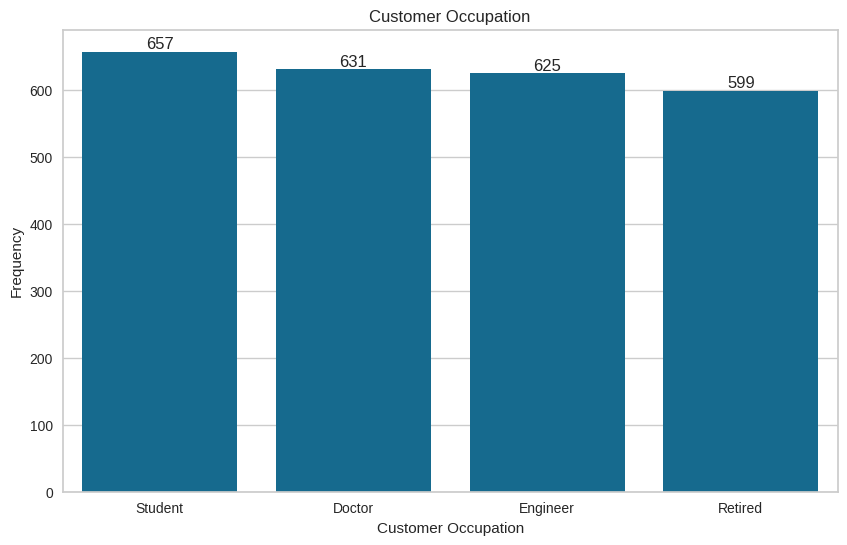

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(df['CustomerOccupation'].value_counts(), orient='v')
plt.title('Customer Occupation')
plt.xlabel('Customer Occupation')
plt.ylabel('Frequency')

for j in range(len(df['CustomerOccupation'].value_counts())):
    value = df['CustomerOccupation'].value_counts().iloc[j]
    plt.text(j, value, value, ha='center', va='bottom')

plt.show()

4. Cek distribusi jumlah transaksi dalam `TransactionAmount`

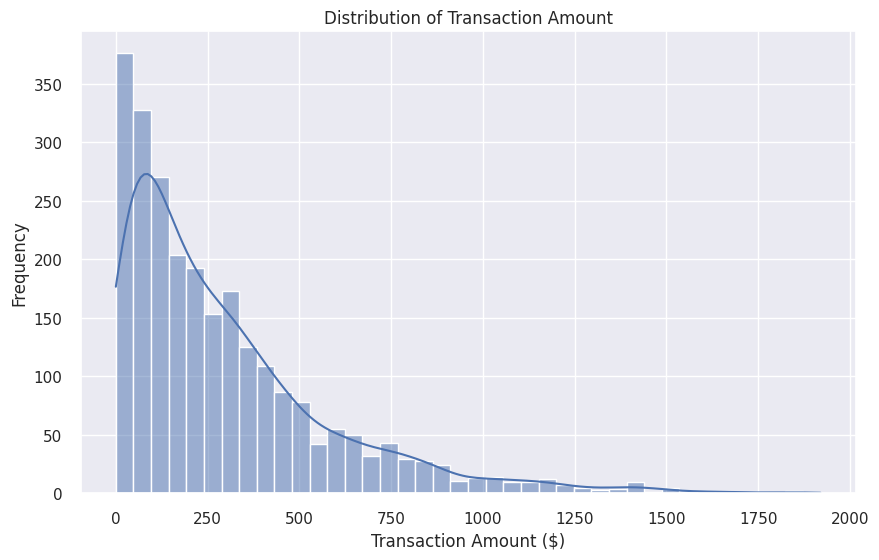

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TransactionAmount'], kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Frequency')
plt.show()

Periksa korelasi antara isi rekening dengan jumlah transaksi

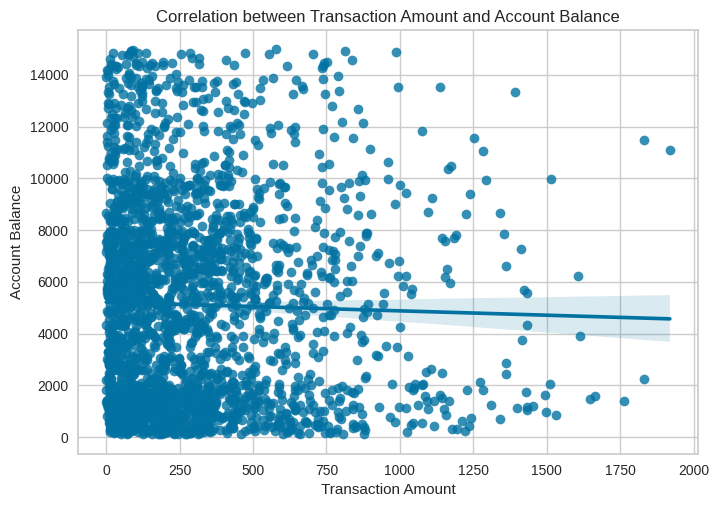

In [16]:
sns.regplot(x='TransactionAmount', y='AccountBalance', data=df)
plt.title('Correlation between Transaction Amount and Account Balance')
plt.xlabel('Transaction Amount')
plt.ylabel('Account Balance')
plt.show()

4. Cek isi `TransactionType` dan distribusinya, serta korelasinya dibanding beberapa data lain

In [17]:
df['TransactionType'].unique()

array(['Debit', 'Credit'], dtype=object)

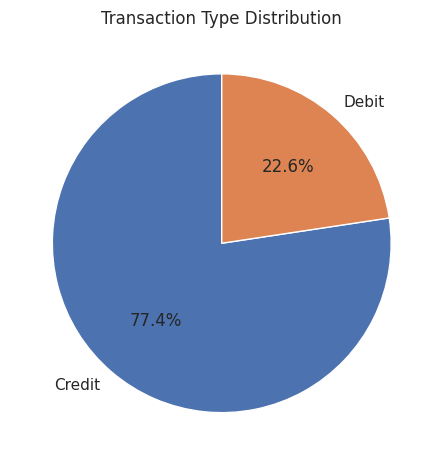

In [20]:
sns.set_theme()

plt.pie(df['TransactionType'].value_counts(), labels=['Credit', 'Debit'], autopct='%1.1f%%', startangle=90)
plt.title('Transaction Type Distribution')
plt.show()

Jumlah Transaksi berdasarkan Tipe Transaksi

Text(0, 0.5, 'Transaction Amount ($)')

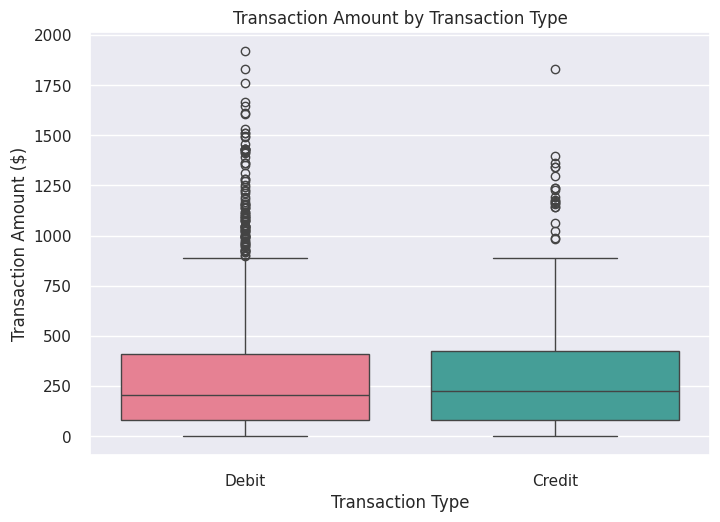

In [21]:
sns.boxplot(x='TransactionType', y='TransactionAmount', data=df, hue='TransactionType', palette='husl', legend=False)
plt.title('Transaction Amount by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Amount ($)')

Durasi Transaksi berdasarkan Tipe Transaksi

Text(0, 0.5, 'Transaction Duration')

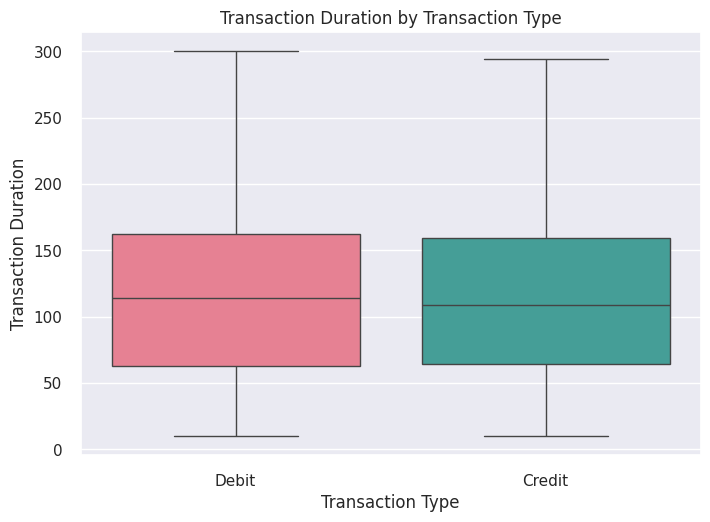

In [22]:
sns.boxplot(x='TransactionType', y='TransactionDuration', data=df, hue='TransactionType', palette='husl', legend=False)
plt.title('Transaction Duration by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Duration')

5. Cek isi `Location` dan distribusinya

In [23]:
df['Location'].unique()

array(['San Diego', 'Houston', 'Mesa', 'Raleigh', 'Atlanta',
       'Oklahoma City', 'Seattle', 'Indianapolis', 'Detroit', 'Nashville',
       'Albuquerque', 'Memphis', 'Louisville', 'Denver', 'Austin',
       'Columbus', 'Los Angeles', 'Las Vegas', 'Fort Worth', 'Miami',
       'Milwaukee', 'Baltimore', 'New York', 'San Francisco', 'San Jose',
       'San Antonio', 'Philadelphia', 'Charlotte', 'Tucson', 'Chicago',
       'Sacramento', 'Kansas City', 'Omaha', 'Virginia Beach', 'Dallas',
       'Boston', 'Jacksonville', 'Phoenix', 'Washington', 'El Paso',
       'Colorado Springs', 'Fresno', 'Portland'], dtype=object)

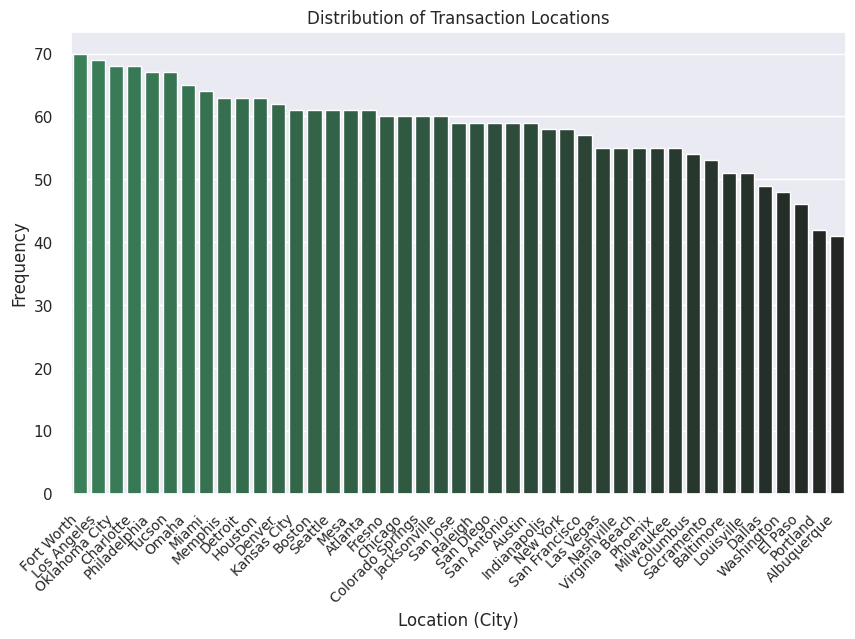

In [25]:
plt.figure(figsize=(10, 6))
location_order = df['Location'].value_counts().index

palette = sns.dark_palette("seagreen", len(location_order), reverse=True)

location_to_color = dict(zip(location_order, palette))

sns.countplot(x='Location', data=df, hue = 'Location', order=location_order, palette=location_to_color)
plt.title('Distribution of Transaction Locations')
plt.xlabel('Location (City)')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right', fontsize = 10)
plt.show()

6. Cek isi `Channel` dan distribusinya

In [26]:
df['Channel'].unique()

array(['ATM', 'Online', 'Branch'], dtype=object)

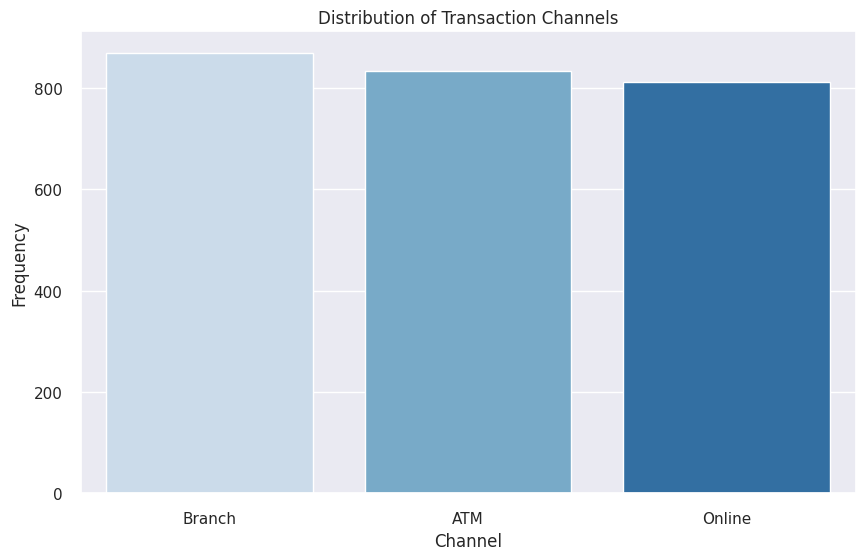

In [27]:
plt.figure(figsize=(10, 6))
channel_order = df['Channel'].value_counts().index

palette = sns.color_palette("Blues", len(channel_order))

channel_to_color = dict(zip(channel_order, palette))

sns.countplot(x='Channel', data=df, hue = 'Channel', order=channel_order, palette=channel_to_color)
plt.title('Distribution of Transaction Channels')
plt.xlabel('Channel')
plt.ylabel('Frequency')
plt.show()

Membandingkan saluran transaksi dengan durasinya, berdasarkan tipe transaksi (debit/credit)

Text(0, 0.5, 'Transaction Duration')

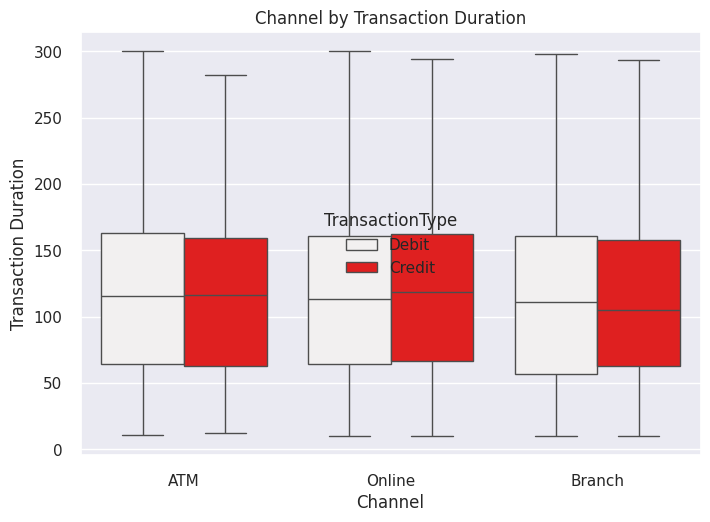

In [28]:
sns.boxplot(x='Channel', y='TransactionDuration', data=df, hue='TransactionType', palette='light:red', legend=True)
plt.title('Channel by Transaction Duration')
plt.xlabel('Channel')
plt.ylabel('Transaction Duration')

7. Cek perbandingan antara `LoginAttempts` dengan beberapa parameter lain

Karena jumlah usaha login yang banyak kemungkinan menandakan usaha pembajakan/penipuan, maka kita coba jelajahi korelasinya dengan beberapa data lain

Pertama, usaha login dengan jumlah transaksi, dibagi berdasarkan tipe transaksi (debit/credit)

Text(0, 0.5, 'Transaction Amount ($)')

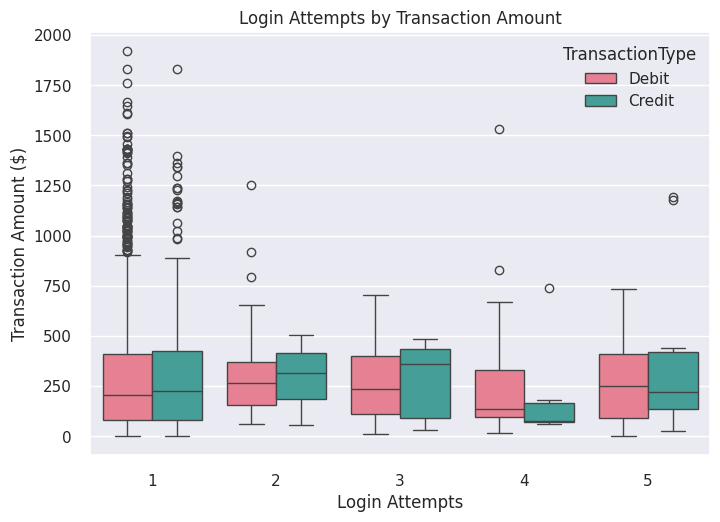

In [29]:
sns.boxplot(x='LoginAttempts', y='TransactionAmount', data=df, hue='TransactionType', palette='husl')
plt.title('Login Attempts by Transaction Amount')
plt.xlabel('Login Attempts')
plt.ylabel('Transaction Amount ($)')

Kedua, usaha login dengan umur pengguna

Text(0, 0.5, 'Customer Age')

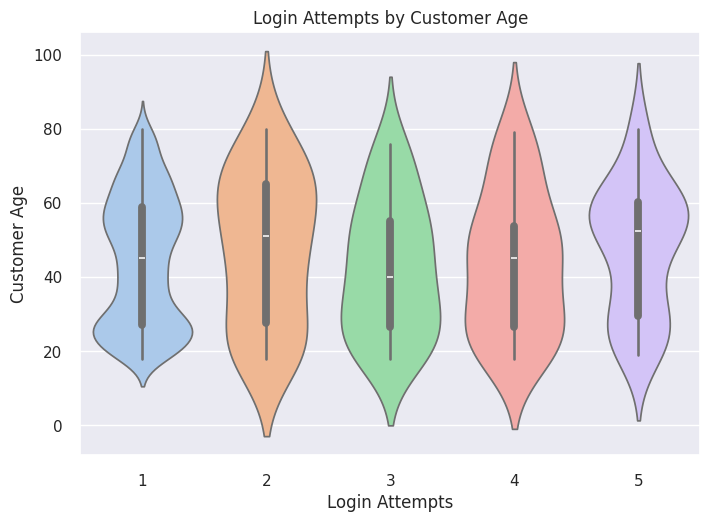

In [30]:
sns.violinplot(x='LoginAttempts', y='CustomerAge', data=df, hue='LoginAttempts', palette='pastel', legend=False)
plt.title('Login Attempts by Customer Age')
plt.xlabel('Login Attempts')
plt.ylabel('Customer Age')

Ketiga, usaha login dengan saluran transaksi

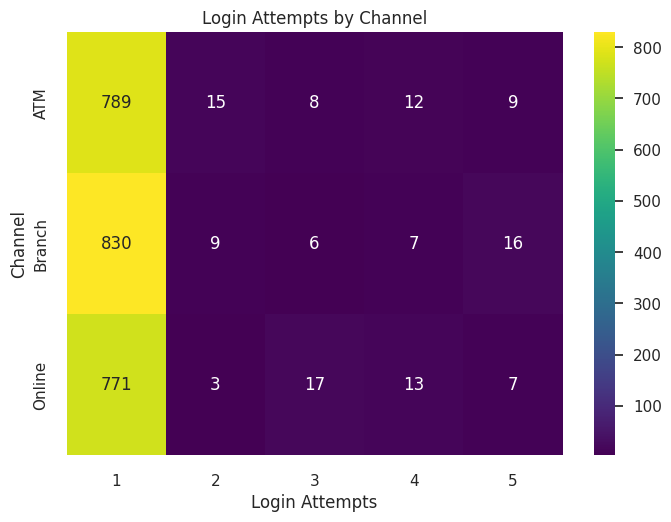

In [32]:
ct = pd.crosstab(df['Channel'], df['LoginAttempts'])

sns.heatmap(ct, cmap='viridis', annot=True, fmt='d')
plt.title('Login Attempts by Channel')
plt.xlabel('Login Attempts')
plt.ylabel('Channel')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

1. Ubah tipe data yang perlu diubah

In [33]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate']) # Dari object menjadi tanggal
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate']) # Dari object menjadi tanggal

df[['TransactionDate', 'PreviousTransactionDate']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionDate          2512 non-null   datetime64[ns]
 1   PreviousTransactionDate  2512 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 39.4 KB


2. Encoding data kategorikal

In [34]:
cols = ['TransactionType', 'Channel', 'CustomerOccupation', 'Location']
encoders = {}

for col in cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionType_encoded,Channel_encoded,CustomerOccupation_encoded,Location_encoded
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08,1,0,0,36
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,1,0,0,15
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,1,2,3,23
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06,1,2,3,33
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39,0,2,3,1


3. Binning data

- Binning data umur pelanggan

   CustomerAge AgeGroup
0           70    63-71
1           68    63-71
2           19    18-26
3           26    18-26
4           26    18-26
5           18    18-26
6           37    36-44
7           67    63-71
8           51    45-53
9           55    54-62


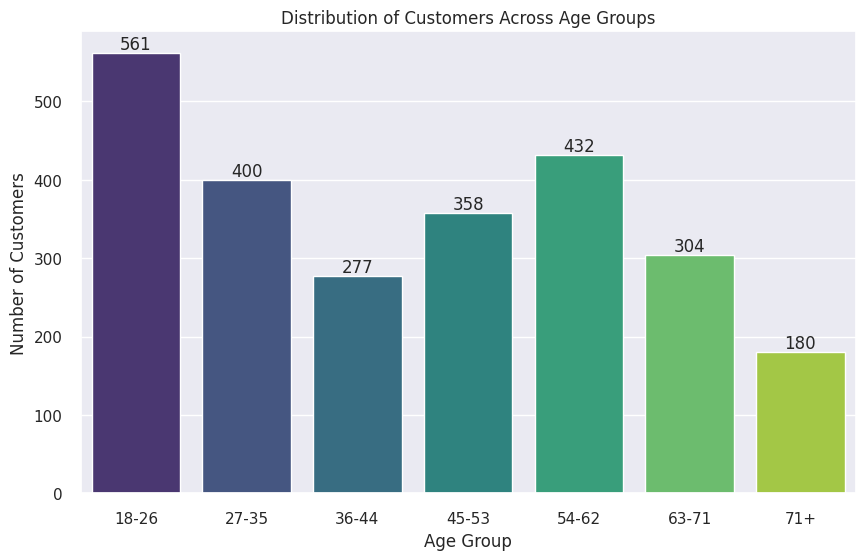

In [35]:
# Binning umur seperti saat EDA
age_bin = [17.5, 26.5, 35.5, 44.5, 53.5, 62.5, 71.5, float('inf')]  # Define bins using numeric values
age_label = ["18-26", "27-35", "36-44", "45-53", "54-62", "63-71", "71+"]  # Keep labels as strings
df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=age_bin, labels=age_label, right=False)

# Display the updated DataFrame
print(df[['CustomerAge', 'AgeGroup']].head(10))

plt.figure(figsize=(10, 6))
sns.countplot(x='AgeGroup', data=df, hue = 'AgeGroup', palette='viridis')
plt.title('Distribution of Customers Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

# Menambahkan label jumlah pelanggan di atas setiap bar
for i, age_group in enumerate(age_label):
    count = df['AgeGroup'].value_counts().get(age_group, 0)
    plt.text(i, count, count, ha='center', va='bottom')

plt.show()

4. Feature Engineering

- Cari tahu persentase antara nominal transaksi dengan isi rekening

In [36]:
# Calculate the percentage of transaction amount compared to account balance
df['TransactionPercentage'] = (df['TransactionAmount'] / df['AccountBalance']) * 100

# Handle potential infinite values resulting from zero account balance
df['TransactionPercentage'] = df['TransactionPercentage'].replace([np.inf, -np.inf], np.nan)
df['TransactionPercentage'] = df['TransactionPercentage'].fillna(0)

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionType_encoded,Channel_encoded,CustomerOccupation_encoded,Location_encoded,AgeGroup,TransactionPercentage
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,...,81,1,5112.21,2024-11-04 08:08:08,1,0,0,36,63-71,0.275615
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,...,141,1,13758.91,2024-11-04 08:09:35,1,0,0,15,63-71,2.734519
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,...,56,1,1122.35,2024-11-04 08:07:04,1,2,3,23,18-26,11.252283
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,...,25,1,8569.06,2024-11-04 08:09:06,1,2,3,33,18-26,2.153095
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,...,198,1,7429.40,2024-11-04 08:06:39,0,2,3,1,18-26,0.181037


In [37]:
min_percentage = df['TransactionPercentage'].min()
max_percentage = df['TransactionPercentage'].max()

print(f"Minimum Transaction Percentage: {min_percentage}")
print(f"Maximum Transaction Percentage: {max_percentage}")


Minimum Transaction Percentage: 0.004470160283184654
Maximum Transaction Percentage: 789.5988258317026


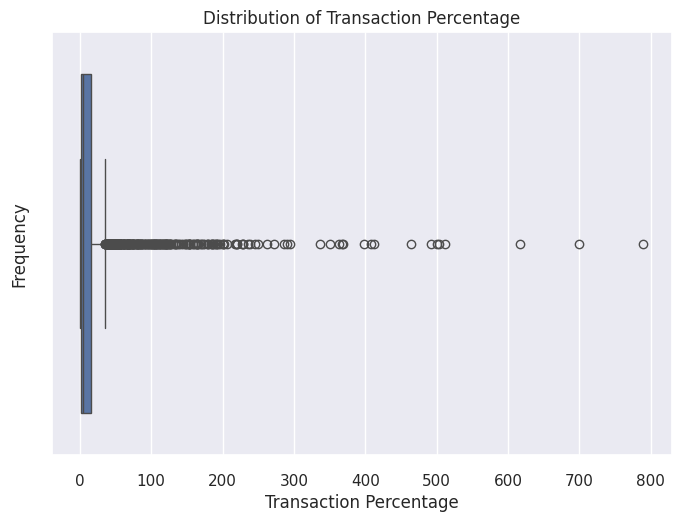

In [38]:
sns.boxplot(df['TransactionPercentage'], orient='h')
plt.title('Distribution of Transaction Percentage')
plt.xlabel('Transaction Percentage')
plt.ylabel('Frequency')
plt.show()

Ada lumayan banyak transaksi yang nominalnya melebihi saldo rekening, bahkan hingga 800%. Logikanya, dari mana uang untuk transaksi itu kalau saldo rekening nya saja tidak mencukupi?

Sehingga, data nominal transaksi yang melebihi 100% dari saldo rekening dianggap sebagai outlier dan akan dihapus

In [39]:
for col in df['TransactionPercentage']:
    # Melihat outlier dengan IQR (Interquartile Range)
    Q1 = df['TransactionPercentage'].quantile(0.25)
    Q3 = df['TransactionPercentage'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df['TransactionPercentage'] < lower_bound) | (df['TransactionPercentage'] > upper_bound)]

# Hapus data di atas 100%
delete_pct = df[df['TransactionPercentage'] > 100].index

df = df.drop(index=delete_pct)

# Lihat maximum dan minimum, serta data setelah pembersihan
print(lower_bound)
print(upper_bound)
df['TransactionPercentage'].describe()

-18.208203873123175
35.1899535308721


,TransactionPercentage
count,2393.000000
mean,11.016904
std,16.152740
min,0.004470
25%,1.711934
50%,4.811914
75%,12.489325
max,99.164814


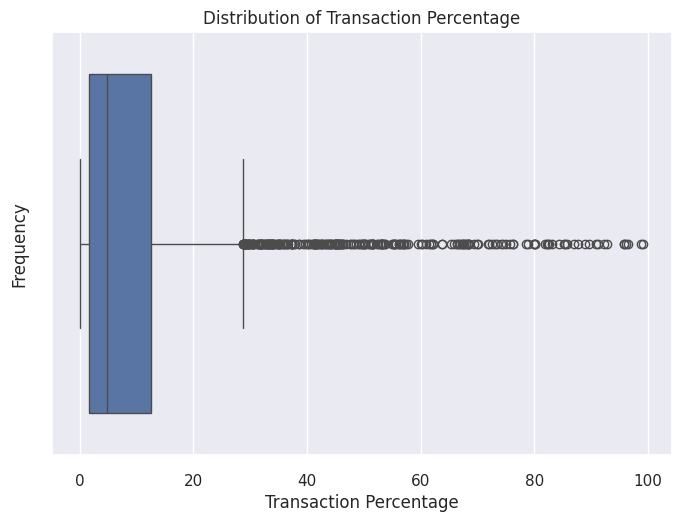

<bound method DataFrame.value_counts of      TransactionID AccountID  TransactionAmount     TransactionDate  \
9         TX000010   AC00385             815.96 2023-03-31 16:06:57   
14        TX000015   AC00085             166.99 2023-02-13 16:53:57   
16        TX000017   AC00317             555.80 2023-10-30 16:52:49   
26        TX000027   AC00441             246.93 2023-04-17 16:37:01   
47        TX000048   AC00439             510.24 2023-10-09 16:29:40   
...            ...       ...                ...                 ...   
2467      TX002468   AC00412              69.80 2023-05-02 16:01:04   
2469      TX002470   AC00054             179.62 2023-11-15 16:00:38   
2482      TX002483   AC00347             411.47 2023-12-25 16:25:42   
2499      TX002500   AC00089             557.78 2023-05-30 16:55:04   
2508      TX002509   AC00322             251.54 2023-03-22 17:36:48   

     TransactionType       Location DeviceID       IP Address MerchantID  \
9              Debit      Nashv

In [40]:
sns.boxplot(df['TransactionPercentage'], orient='h')
plt.title('Distribution of Transaction Percentage')
plt.xlabel('Transaction Percentage')
plt.ylabel('Frequency')
plt.show()

print(df[df['TransactionPercentage'] > upper_bound].value_counts)

- Mencari tau frekuensi transaksi tiap Rekening

In [41]:
df['TransactionFrequency'] = df.groupby('AccountID')['TransactionID'].transform('count')

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionType_encoded,Channel_encoded,CustomerOccupation_encoded,Location_encoded,AgeGroup,TransactionPercentage,TransactionFrequency
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,...,1,5112.21,2024-11-04 08:08:08,1,0,0,36,63-71,0.275615,4
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,...,1,13758.91,2024-11-04 08:09:35,1,0,0,15,63-71,2.734519,6
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,...,1,1122.35,2024-11-04 08:07:04,1,2,3,23,18-26,11.252283,4
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,...,1,8569.06,2024-11-04 08:09:06,1,2,3,33,18-26,2.153095,8
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,...,1,7429.40,2024-11-04 08:06:39,0,2,3,1,18-26,0.181037,6


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [42]:
df_use = df[[
    'TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts',
    'AccountBalance', 'TransactionFrequency',
    'TransactionType_encoded', 'CustomerOccupation_encoded', 'Channel_encoded', 'Location_encoded',
    'TransactionPercentage'
]]

In [43]:
silhouette_scores = []
inertia = []

for n_clusters in range(2,11):
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init = 20, random_state=42)
    kmeans.fit(df_use)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_use, kmeans.labels_))

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

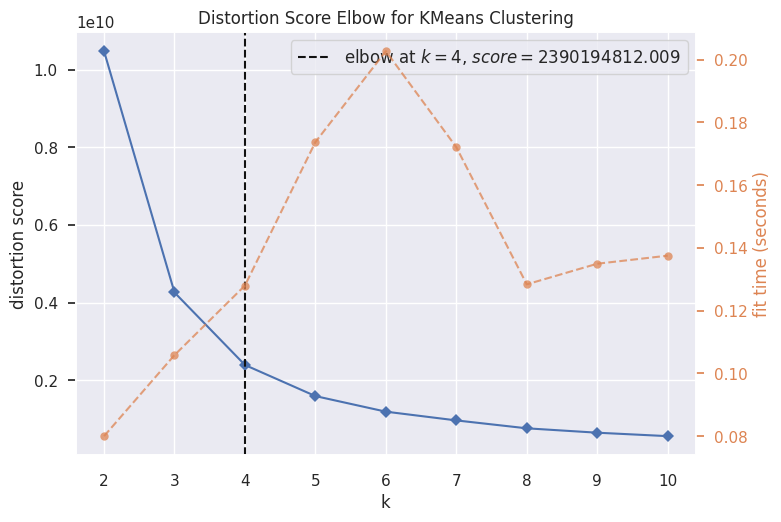

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [44]:
visualizer = KElbowVisualizer(kmeans, n=(2, 10))
visualizer.fit(df_use)
visualizer.show()

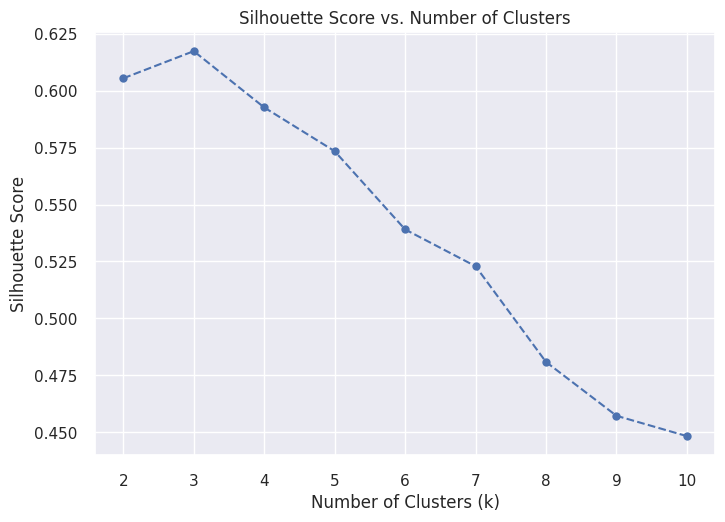

In [45]:
plt.plot(range(2,11), silhouette_scores, marker='o', linestyle='dashed')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters")
plt.show()

## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

<Axes: >

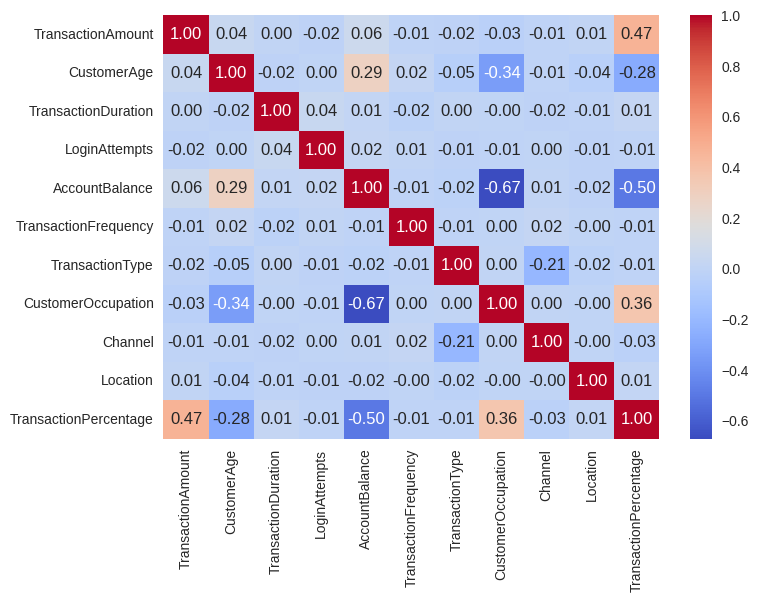

In [ ]:
sns.heatmap(df_use.corr(), annot=True, cmap='coolwarm', fmt='.2f')

Melihat tabel korelasi, fitur yang cocok untuk digunakan adalah `TransactionPercentage, TransactionAmount, CustomerAge, AccountBalance, dan CustomerOccupation`.

Karena `CustomerOccupation` disini adalah data kategorikal, maka tipe data yang digunakan pada dataframe setelah feature selection adalah `CustomerOccupation_encoded`

In [57]:
df_feat = df[[
    'TransactionAmount', 'CustomerAge', 'AccountBalance', 'TransactionPercentage',
    'CustomerOccupation_encoded'
]].copy()

df_feat.head()

,TransactionAmount,CustomerAge,AccountBalance,TransactionPercentage,CustomerOccupation_encoded
0,14.09,70,5112.21,0.275615,0
1,376.24,68,13758.91,2.734519,0
2,126.29,19,1122.35,11.252283,3
3,184.50,26,8569.06,2.153095,3
4,13.45,26,7429.40,0.181037,3


In [58]:
# Membangun 3 model dengan 3 cluster, 4 cluster, dan 6 cluster untuk perbandingan
kmeans_3 = KMeans(n_clusters=3, init='k-means++', n_init = 20, max_iter=300, random_state=42)
kmeans_4 = KMeans(n_clusters=4, init='k-means++', n_init = 20, max_iter=300, random_state=42)
kmeans_6 = KMeans(n_clusters=6, init='k-means++', n_init = 20, max_iter=300, random_state=42)

kmeans_3labels = kmeans_3.fit_predict(df_feat)
kmeans_4labels = kmeans_4.fit_predict(df_feat)
kmeans_6labels = kmeans_6.fit_predict(df_feat)

In [59]:
silhouette_3 = silhouette_score(df_feat, kmeans_3.labels_)
silhouette_4 = silhouette_score(df_feat, kmeans_4.labels_)
silhouette_6 = silhouette_score(df_feat, kmeans_6.labels_)

print(f"Silhouette Score for k=3: {silhouette_3}")
print(f"Silhouette Score for k=4: {silhouette_4}")
print(f"Silhouette Score for k=6: {silhouette_6}")

Silhouette Score for k=3: 0.618683548969414
Silhouette Score for k=4: 0.5947317546643489
Silhouette Score for k=6: 0.5431658518420845


3 Cluster memberikan Silhouette Score yang paling tinggi dibanding varian model dengan 4 dan 6 cluster. Maka, model dengan 3 cluster digunakan.

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


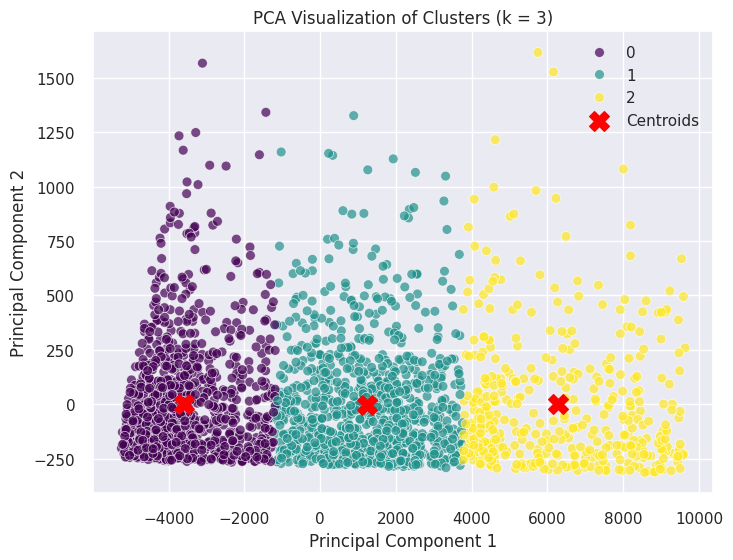

In [61]:
# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_feat)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df_pca[:, 0], y=df_pca[:, 1], hue=kmeans_3.labels_,
    palette="viridis", s=50, alpha=0.7
)

# Plot centroids (after transforming them with PCA)
centroids_pca = pca.transform(kmeans_3.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker="X", s=200, c="red", label="Centroids"
    )

plt.title(f"PCA Visualization of Clusters (k = 3)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [51]:
df_feat["Cluster"] = kmeans_3labels
df_feat['PC1'] = df_pca[:, 0]  # Assign the first principal component to 'PC1'
df_feat['PC2'] = df_pca[:, 1]  # Assign the second principal component to 'PC2'

### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [52]:
df_feat['CustomerOccupation'] = encoders['CustomerOccupation'].inverse_transform(
    df_feat['CustomerOccupation_encoded'].astype(int)
)

df_feat.head()

,TransactionAmount,CustomerAge,AccountBalance,TransactionPercentage,CustomerOccupation_encoded,Cluster,PC1,PC2,CustomerOccupation
0,14.09,70,5112.21,0.275615,0,1,-236.169038,-262.693193,Doctor
1,376.24,68,13758.91,2.734519,0,2,8411.978360,62.603724,Doctor
2,126.29,19,1122.35,11.252283,3,0,-4225.586003,-133.316590,Student
3,184.50,26,8569.06,2.153095,3,1,3221.311141,-107.053160,Student
4,13.45,26,7429.40,0.181037,3,1,2080.931495,-273.239676,Student


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [55]:
summary = df_feat.drop(columns=['CustomerOccupation','CustomerOccupation_encoded']).groupby("Cluster", as_index=False).mean()
summary_cat = (
    df_feat.groupby("Cluster", as_index=False)['CustomerOccupation']
    .agg(lambda x: x.mode().iloc[0])
)

cluster_summary = summary.merge(summary_cat, on="Cluster", how="left")

cluster_summary = cluster_summary.drop(columns=["CustomerOccupation_x"], errors="ignore")
cluster_summary.rename(columns={"CustomerOccupation_y": "CustomerOccupation"}, inplace=True)
(cluster_summary)

,Cluster,TransactionAmount,CustomerAge,AccountBalance,TransactionPercentage,PC1,PC2,CustomerOccupation
0,0,264.246536,39.169378,1745.303502,20.183816,-3602.037271,2.218119,Student
1,1,279.596559,51.590568,6585.689078,4.441236,1238.404083,-3.468682,Engineer
2,2,306.805807,47.542169,11633.250771,2.717326,6286.019130,2.212882,Doctor


# **Cluster 0**
- Rata-rata Jumlah Transaksi  : USD 264.24
- Rata-rata Umur Nasabah      : 39.16 Tahun
- Rata-rata Saldo Rekening    : USD 1745.30
- Rata-rata Persentase Jumlah Transaksi per Saldo : 20.18%
- Mayoritas Pekerjaan Nasabah : Pelajar

Analisis:
Cluster ini didominasi oleh nasabah pelajar, yang rata-rata transaksinya terdiri atas 20% dari saldo rekeningnya. Meskipun rata-rata nominal transaksinya paling rendah dari cluster lainnya, tingginya persentase ini disebabkan oleh rata-rata saldo rekening yang jauh lebih rendah dibandingkan cluster lainnya. Rendahnya saldo rekening juga dapat disebabkan karena mayoritas pekerjaan nasabah pada cluster ini yaitu Pelajar.

# **Cluster 1**
- Rata-rata Jumlah Transaksi  : USD 279.59
- Rata-rata Umur Nasabah      : 51.59 Tahun
- Rata-rata Saldo Rekening    : USD 6585.68
- Rata-rata Persentase Jumlah Transaksi per Saldo : 4.44%
- Mayoritas Pekerjaan Nasabah : Insinyur

Analisis:
Cluster ini didominasi oleh nasabah Insinyur,  yang rata-rata saldo rekening nya jauh di atas pelajar pada cluster 0. Meskipun rata-rata nominal transaksinya tidak jauh lebih tinggi dibanding pada cluster 0 -hanya terpaut 15 dolar-, namun dengan rata-rata saldo rekening yang jauh lebih tinggi persentase nominal transaksi terhadap saldo menurun drastis dibandingkan pada cluster 0, hingga ke angka 4%

# **Cluster 2**
- Rata-rata Jumlah Transaksi  : USD 306.80
- Rata-rata Umur Nasabah      : 47.54 Tahun
- Rata-rata Saldo Rekening    : USD 11633.25
- Rata-rata Persentase Jumlah Transaksi per Saldo : 2.71%
- Mayoritas Pekerjaan Nasabah : Dokter

Analisis:
Cluster ini didominasi nasabah pekerjaan dengan gaji tertinggi, yaitu Dokter. Tidak heran mengapa rata-rata saldo rekening pada cluster ini menembus angka USD 11000. Kemudian, dengan rata-rata nominal transaksi yang tidak terpaut jauh pula dari cluster lainnya, turut berkontribusi terhadap rendahhnya persentase nominal transaksi terhadap saldo. Di angka 2.7%, angka ini adalah paling rendah dibanding cluster lainnya.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [ ]:
df_feat.to_csv("transaction_cluster.csv", index=False)

print("Dataset berhasil diekspor sebagai 'transaction_cluster.csv'")

Dataset berhasil diekspor sebagai 'transaction_cluster.csv'
